# Exercise 13

This exercise is based on Chapter 5 (Classification of Land Cover) of the Open Source Geoprocessing Tutorial.

The material can be found in: `GSP538/raster_book/notebooks/chapter_5_classification.ipynb`

#### Notes on Textbook

- This chapter is short and has more code than text, at least relative to the GDS textbook you have been working with most of the semester.
- This book was written by different authors from the GDS textbook, so there might be some differences in the coding style. 
  - Notice that they use all the same packages you have already seen in the GDS textbook (and the data science book).
  - Notice that they like using intermediate variables. This results is many short lines of code that tend to do one thing, but the tradeoff is more variables to keep track of as you read from line-to-line in the code.
- The author appears to refer to "Subtidal Haline" as "water", probably because Subtidal Haline is continuously submerged.

#### The following questions require you to run Python code.

This exercise is different the previous ones. Instead of extending your knowledge by working with new data, you will instead augment the chapter you just read with further analyses. All of the Markdown cells from the chapter have been removed. The code cells remain with varying degrees of modification for clarity.

1. The following four cells do two things. a) Import most of the packages you will need. b) Prep the raw raster data for use in the analysis: each band is stored in a separate TIFF file; the code uses Rasterio to combine them into a single file. The two relevant objects you need are `meta` and `full_dataset`. 
   - Run the four cells.
   - In a Markdown cell:
     - Give the full file path to one of the original 8 files (Hint: find the file on your hard drive (using Finder or Windows Explorer) and get the path).
     - Give the full file path to the new file created (Hint: find the file on your hard drive (using Finder or Windows Explorer) and get the path).
   - In a code cell type `meta` to the see the metadata contents
   - In a code cell print `full_dataset.shape`, `full_dataset.count`, `full_dataset.crs`, `full_dataset.dtypes`
   - Briefly discuss:
     - Shape of the raster (width and height; total number of pixels)
     - The number of bands
     - What each represents (Note: you will need to go to Google for what each band means; Hint: the number of bands listed for this response needs to match the previous response)
     - The projection (give the EPSG number and the common name for this)
     - The data type used to store the pixel values (the Python label and the practical meaning of this)

In [1]:
import os

import warnings
warnings.filterwarnings("ignore")

import rasterio
from rasterio.mask import mask
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import mapping

In [2]:
sentinal_fp = "../raster_book/data/sentinel-2/"
# find every file in the sentinal_fp directory
sentinal_band_paths = [os.path.join(sentinal_fp, f) for f in os.listdir(sentinal_fp) 
                       if os.path.isfile(os.path.join(sentinal_fp, f))]
sentinal_band_paths.sort()

In [3]:
# create a products directory within the data dir which won't be uploaded to Github
img_dir = '../raster_book/data/products/'

# check to see if the dir it exists, if not, create it
if not os.path.exists(img_dir):
    os.makedirs(img_dir)

# filepath for image we're writing out
img_fp = img_dir + 'sentinel_bands.tif'

# Read metadata of first file and assume all other bands are the same
with rasterio.open(sentinal_band_paths[0]) as src0:
    meta = src0.meta

# Update metadata to reflect the number of layers
meta.update(count = len(sentinal_band_paths))

# Read each layer and write it to stack
with rasterio.open(img_fp, 'w', **meta) as dst:
    for id, layer in enumerate(sentinal_band_paths, start=1):
        with rasterio.open(layer) as src1:
            dst.write_band(id, src1.read(1))

In [4]:
full_dataset = rasterio.open(img_fp)
img_rows, img_cols = full_dataset.shape
img_bands = full_dataset.count

2. The following cell clips the source raster down to a smaller size. The clipped region will be called the "study area."
   - Run the cell.
   - How many pixels are in the study area?
   - Which bands did the authors use for plotting the study area? (Note: give the answer in words not the band numbers.)
   - Plot the full image (before it was clipped to the study area) using the same bands as the authors used for the study area. (Note: It is possible to do this with one line of code.)
   - Give a brief description of the study area relative to the full image.

(3, 450, 1150)


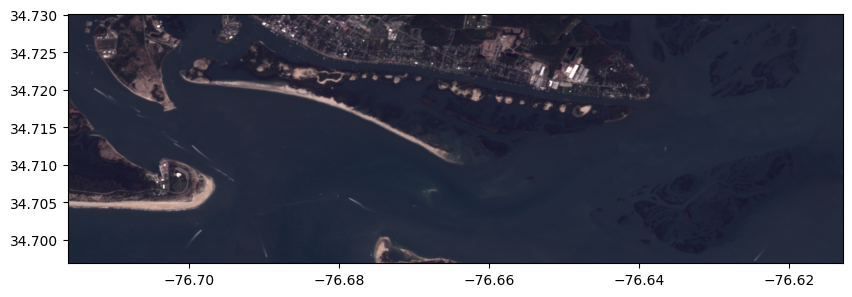

In [5]:
import matplotlib.pyplot as plt
from rasterio.plot import show

clipped_img = full_dataset.read([4,3,2])[:, 150:600, 250:1400]
print(clipped_img.shape)
fig, ax = plt.subplots(figsize=(10,7))
show(clipped_img[:, :, :], ax=ax, transform=full_dataset.transform); # add the transform arg to get it in lat long coords

3. The following cell reads in the training data and align its projection with that of the raster data.
   - Run the cell.
   - Plot the training data (i.e., the `shapefile` GeoDataFrame) using the `explore()` method. Use the `Classname` column to categorize the data, include a legend and add the `tiles='Esri WorldImagery'` parameter to present a satellite image as the basemap.
   - Investigate the attributes of the training data. Run `value_counts()` on the `Classname` column.
   - Zoom and pan the map to see all the land use categories.
   - Briefly describe the training data.
   - What might be a challenge in having fixed polygons like this for classification in a coastal area?
   - What major land use type in the study area is not included in the training data?

In [6]:
shapefile = gpd.read_file('../raster_book/data/rcr/rcr_landcover.shp')

shapefile = shapefile.to_crs({'init': 'epsg:4326'})

4. As you saw in the previous question, each training polygon is a single land cover class. The cell below grabs the pixels associated with each polygon and assigns the land cover class label from the polygon to each of the pixels it intersects. The result is two numpy arrays: `X` and `y`.
   - What is the exact shape of the `X` array? Explain what each dimension means.
   - What do the values in the cells of the `X` array represent? The code below fixes a typo in the book (`np.int8` versus `np.uint8`). Why was this change needed? (Hint: This question relates to stuff you learned in GSP 520 and/or GSP 531.)
   - What is the exact shape of the `y` array? Explain what each dimension means.
   - What do the values in the cells of the `y` array represent? What are the possible values any cell in the array can take?

In [7]:
# The book incorrectly used np.int8
X = np.array([], dtype=np.uint8).reshape(0,8) # pixels for training
y = np.array([], dtype=np.str_) # labels for training

geoms = shapefile.geometry

# extract the raster values within the polygon 
with rasterio.open(img_fp) as src:
    band_count = src.count
    for index, geom in enumerate(geoms):
        feature = [mapping(geom)]

        # the mask function returns an array of the raster pixels within this feature
        out_image, out_transform = mask(src, feature, crop=True) 
        # eliminate all the pixels with 0 values for all 8 bands - AKA not actually part of the shapefile
        out_image_trimmed = out_image[:,~np.all(out_image == 0, axis=0)]
        # eliminate all the pixels with 255 values for all 8 bands - AKA not actually part of the shapefile
        out_image_trimmed = out_image_trimmed[:,~np.all(out_image_trimmed == 255, axis=0)]
        # reshape the array to [pixel count, bands]
        out_image_reshaped = out_image_trimmed.reshape(-1, band_count)
        # append the labels to the y array
        y = np.append(y,[shapefile["Classname"][index]] * out_image_reshaped.shape[0]) 
        # stack the pixels onto the pixel array
        X = np.vstack((X,out_image_reshaped))        

5. The following cell produces three plots of diagnostics on training data. Give a brief interpretation of the plots in your own words.

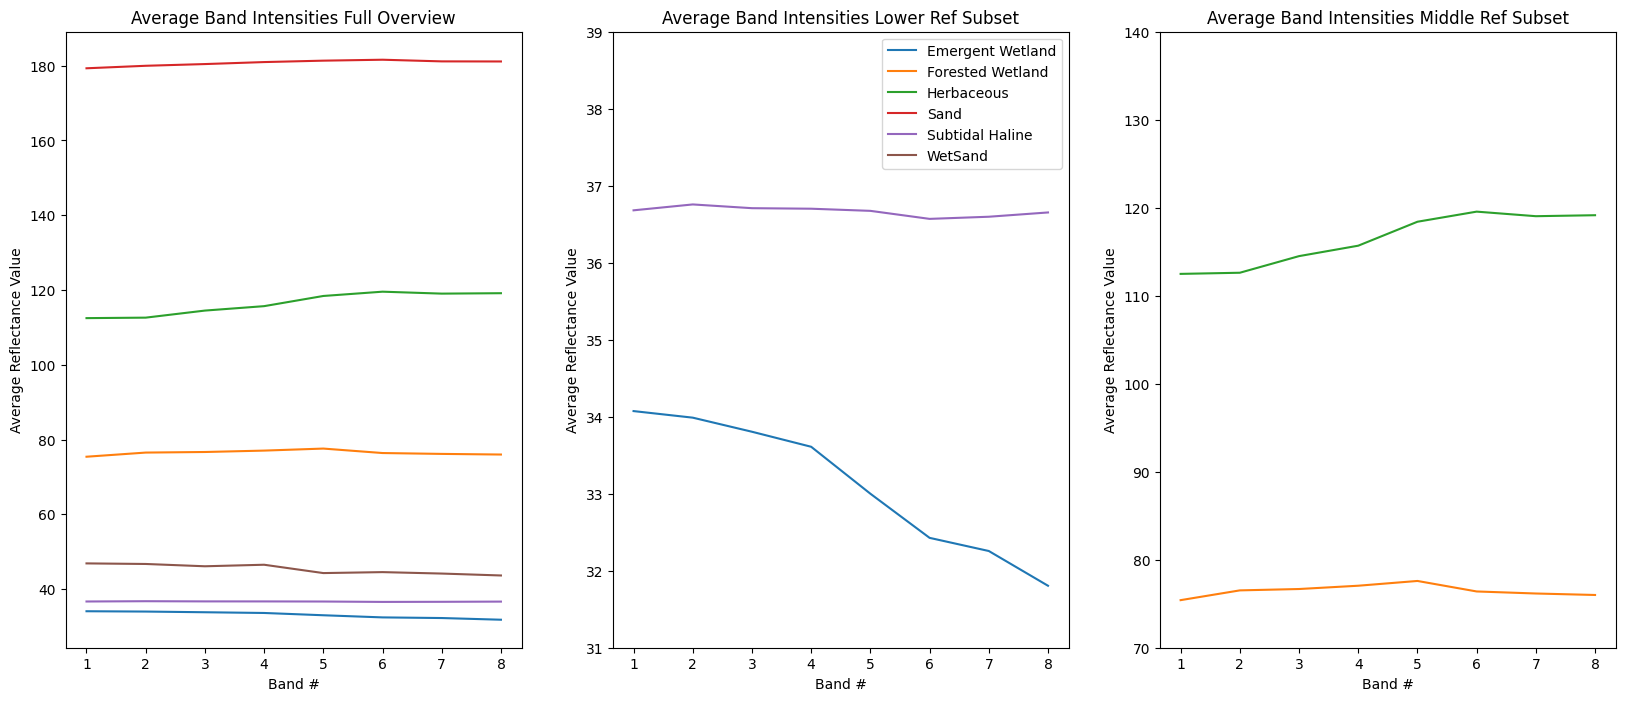

In [8]:
fig, ax = plt.subplots(1,3, figsize=[20,8])

# numbers 1-8
band_count = np.arange(1,9)

classes = np.unique(y)
for class_type in classes:
    band_intensity = np.mean(X[y==class_type, :], axis=0)
    ax[0].plot(band_count, band_intensity, label=class_type)
    ax[1].plot(band_count, band_intensity, label=class_type)
    ax[2].plot(band_count, band_intensity, label=class_type)
# plot them as lines

# Add some axis labels
ax[0].set_ylabel('Average Reflectance Value')
ax[0].set_xlabel('Band #')
ax[1].set_ylabel('Average Reflectance Value')
ax[1].set_xlabel('Band #')
ax[2].set_ylabel('Average Reflectance Value')
ax[2].set_xlabel('Band #')
ax[1].set_ylim(31,39)
ax[2].set_ylim(70,140)

ax[1].legend(loc="upper right")
# Add a title
ax[0].set_title('Average Band Intensities Full Overview')
ax[1].set_title('Average Band Intensities Lower Ref Subset')
ax[2].set_title('Average Band Intensities Middle Ref Subset');

6. The following three cells do the actual prediction work.
   - The first cell trains the model using the training data discussed above. This means that the model is learning which values of bands 1 to 8 are mostly likely to be associated with each land use category. In this case it is using the Naive Bayes approach for learning.
   - The second cell reads in the image data for the whole region (again), and clips it to the same shape as `clipped_img` (i.e., the study area), which was plotted earlier.
   - The third cell reshapes the study area image to match the requirements for prediction. Then runs the prediction function. And finally reshapes the data back. Prediction means that the model looks at bands 1 to 8 for each pixel in the study area, and gives its best guess as to the land use class for that pixel.

   <br>

   - Run the code below.
   - The final product is `class_pred_gnb`.
     - Print its type (Hint: you did this a lot at the beginning of the semester)
     - Print its shape
     - Print the unique values it contains (Hint: you can use `np.unique()`)
     - In your own words, explain the `class_pred_gnb` object and what it means

In [17]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X, y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [18]:
with rasterio.open(img_fp) as src:
    # may need to reduce this image size if your kernel crashes, takes a lot of memory
    img = src.read()[:, 150:600, 250:1400]

In [19]:
from rasterio.plot import reshape_as_image
    
# Take our full image and reshape into long 2d array (nrow * ncol, nband) for classification
reshaped_img = reshape_as_image(img)

class_pred_gnb = gnb.predict(reshaped_img.reshape(-1, 8))

# Reshape our classification map back into a 2D matrix so we can visualize it
class_pred_gnb = class_pred_gnb.reshape(reshaped_img[:, :, 0].shape)

7. The book (and the code in the previous question) uses the Naive Bayes classifier. Another popular classifier is Random Forest. 
   - Read this [overview comparing the two classifiers](https://medium.com/@dannymvarghese/comparative-study-on-classic-machine-learning-algorithms-part-2-5ab58b683ec0) (you can ignore the content on Support Vector Machines) to get a very high level introduction to them. Feel free to read more.
   - Repeat the exercise from the previous question using Random Forest.
   
   <br>

   Notes:
   - For this question, you are just coding the prediction. You will analyze the results in the next question.
   - Your answer needs to be a maximum of 6 lines of code
     - The Naive Bayes approach in the previous question had 9 lines of code (excluding comments).
     - The goal is to recognize the stuff that you can recycle from the previous question because it is already in memory.
   - The first of your 6 lines will be `from sklearn.ensemble import RandomForestClassifier`
   - The second of your 6 lines will be `np.random.seed(999)` (which ensures everyone gets the same result)
   - You will be using `class_pred_gnb` in later questions. Name your Random Forest predictions `class_pred_rf`.

8. Preliminary comparison of the Naive Bayes results to the Random Forest results.
   - Print the shapes of `class_pred_gnb` and `class_pred_rf`
   - Print the classes and number of pixels in each class for `class_pred_gnb` and `class_pred_rf` (Hint: Read the documentation for `np.unique()` to see how to get the counts.)
   - Based on these preliminary results, did the two models give generally similar or generally different results?

9. The following cell plots a photo-style map of the study area and a map of the predictions from the Naive Bayes model. 
   - Run the cell.
   - Plot a map of the Random Forest prediction. (Note: Do not include any unnecessary code in the cell. Make sure the Random Forest map is the same width as the other maps and contains a legend.) 
   - Briefly discuss the similarities and differences between the Naive Bayes and Random Forest predictions from the maps. Which seems to be doing a better job at classification? Explain.

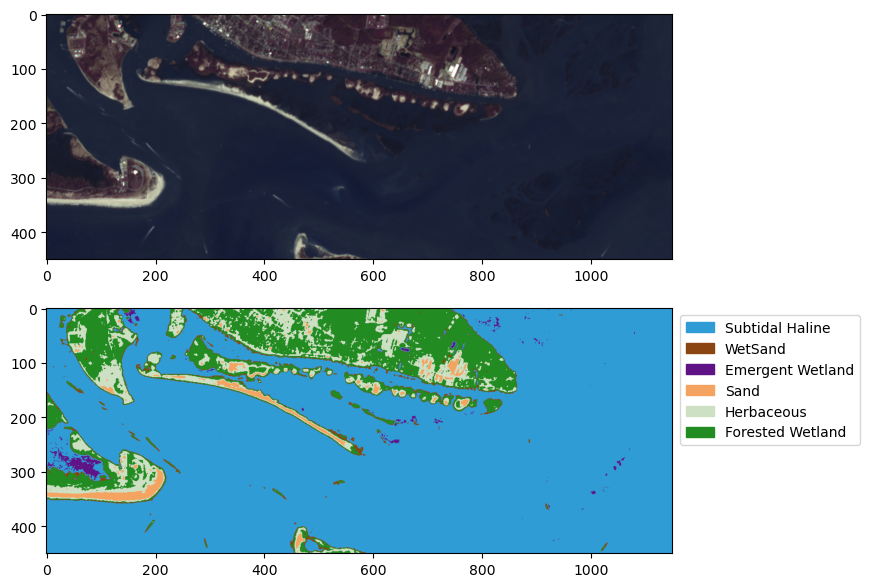

In [27]:
colors = {'Subtidal Haline': (48, 156, 214, 255),  # Blue - Water
          'WetSand': (139,69,19, 255),             # Brown - WetSand
          'Emergent Wetland': (96, 19, 134, 255),  # Purple - Emergent Wetland
          'Sand': (244, 164, 96, 255),             # Tan - Sand
          'Herbaceous': (206, 224, 196, 255),      # Lime - Herbaceous
          'Forested Wetland': (34, 139, 34, 255)}  # Forest Green - Forest 

# legend colors
from matplotlib.patches import Patch
legend_patches = [Patch(color=np.array(rgb)/255, label=label) for label, rgb in colors.items()]

# convert class names into RGB colors
class_pred_gnb_colors = np.vectorize(colors.get)(class_pred_gnb)
class_pred_gnb_colors = np.array(class_pred_gnb_colors)

# plot maps
fig, axs = plt.subplots(2,1,figsize=(10,7))
show(img[[4,3,2], :, :], ax=axs[0])
show(class_pred_gnb_colors[[0,1,2], :, :], ax=axs[1])
axs[1].legend(handles=legend_patches, bbox_to_anchor=(1.31, 1));

10. The following cell plots a photo-style image and Naive Bayes prediction for a part of the study area.
    - Run this cell.
    - Plot a map of the same area for the Random Forest results. (Note: your map should be the same width as the other maps.)
    - Interpret and compare the two prediction maps.

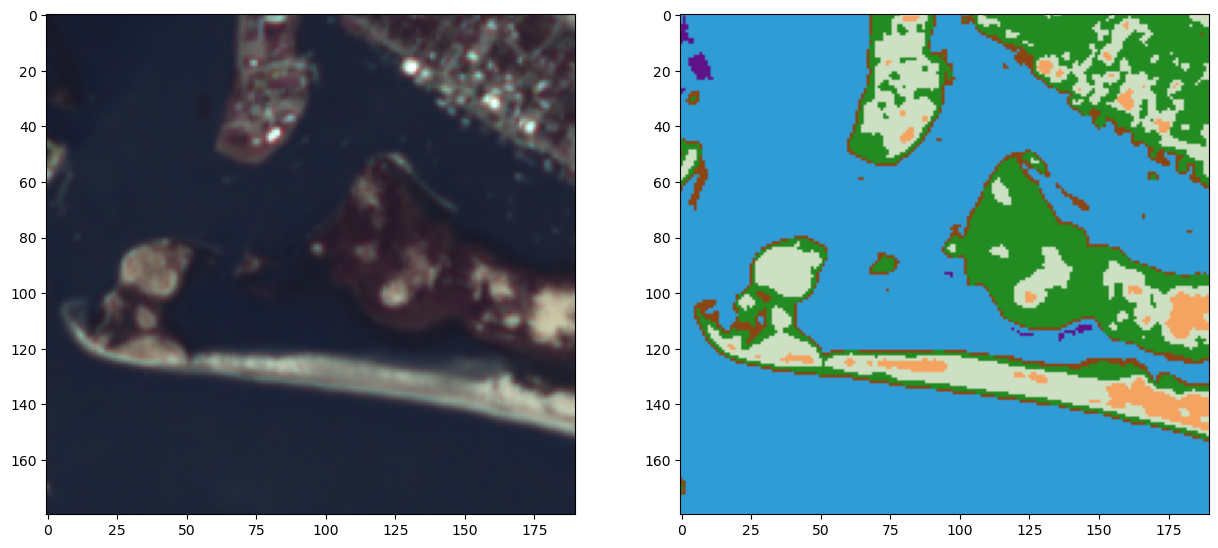

In [29]:
fig, axs = plt.subplots(1,2,figsize=(15,15))

show(img[[4,3,2], 0:180, 160:350], ax=axs[0])
show(class_pred_gnb_colors[[0,1,2], 0:180, 160:350], ax=axs[1]);

11. Naive Bayes and Random Forest are considered "machine learning models." This is not a machine learning course, but these types of models are growing in popularity for "geographic data analysis" so you need to have a basic understanding of them. 

    To this point you have been doing visual comparisons of each model's predictions, and you probably have a favorite. The cells below repeat the analyses above, but in a more rigorous way.
    - The first cell randomly allocates 80% of the `X` and `y` training data for training (`X_train`, `y_train`) and 20% for testing (`X_test`, `y_test`). We assume every pixel in `X` has the correct label in `y`. Splitting the data in this way gives us "correct" data for training the model and "correct" data for testing the model. The weakness of this approach is that we only use 80% of the available training data for training. The strength of this approach is that we now have data for testing how well the models predict.
    - The second cell trains and fits the Naive Bayes and Random Forest models using `X_train` and `y_train`, i.e. using only 80% of the available training data.
    - The third cell uses the Naive Bayes and Random Forest models trained on 80% of the data to predict the classes labels of the remaining 20% of the data.
    - The fourth cell computes the accuracy of each model. The class labels "predicted" in the previous cell can now be compared to the "correct" class labels in `y_test`. There are many measures for evaluating the quality of the predicted class labels, this cell uses the `accuracy_score()` function from the `sklearn` package. It reports the fraction of the labels with correct predictions; a score of 1.0 means that every label in the test data was predicted correctly, a score of 0.0 means that every label in the test data was predicted incorrectly.
    - The fifth and sixth cells return the "confusion matrix" for the Naive Bayes and Random Forest models respectively. The labels going down the left are the true (i.e., "correct") labels from `y_test` and the labels going across the top are the predicted labels. The number in the upper-left cell is the number of true `Emergent Wetland` pixels that were predicted as `Emergent Wetland`. The number in the cell to the immediate right of this one is the number of true `Emergent Wetland` pixels that were predicted as `Forested Wetland`. A model that predicts perfectly would have numbers greater than zero going down the center diagonal and zeros everywhere else.
    - The last cell predicts all the pixels in the study area using Naive Bayes and Random Forest, and then plots the maps.
    
    <br>
    
    - Run the cells.
    - In your own words, briefly explain the difference between this approach and the one used earlier in the exercise.
    - Which model (Naive Bayes or Random Forest) is more accurate according to the accuracy statistic presented? Explain.
    - Based on the confusion matrices, which model (Naive Bayes or Random Forest) does a better job at predicting? Explain.
    - Do the results from the accuracy measure generally match what you see in the confusion matrices? 
    - Based on the confusion matrices, which true class (or classes) is most often incorrectly classified by the Naive Bayes model? Also answer this for the Random Forest model. Explain your answers. (Hint: When answering, consider the rightmost `All` column, which contains the total number of true pixels in each class.)
    - Why does the Random Forest study area map look so much worse than the Naive Bayes map? (Hint: This question is more related to your cartography knowledge than your machine learning knowledge.)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
np.random.seed(9999)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [32]:
# train and fit Naive Bayes using 80% of the training data
gnb_train = GaussianNB()
gnb_train.fit(X_train, y_train);

# train and fit Random Forest using 80% of the training data
rf_train = RandomForestClassifier()
rf_train.fit(X_train, y_train);

In [33]:
# predict the classes of the test data using the Naive Bayes model
y_pred_gnb = gnb_train.predict(X_test)

# predict the classes of the test data using the Random Forest model
y_pred_rf = rf_train.predict(X_test)

In [34]:
print('Naive Bayes accuracy', accuracy_score(y_test, y_pred_gnb))
print('Random Forest accuracy', accuracy_score(y_test, y_pred_rf))

Naive Bayes accuracy 0.3333333333333333
Random Forest accuracy 0.675


In [35]:
pd.crosstab(y_test, y_pred_gnb, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,Emergent Wetland,Forested Wetland,Herbaceous,Sand,Subtidal Haline,WetSand,All
True,,,,,,,
Emergent Wetland,13,4,0,0,1,1,19
Forested Wetland,3,2,13,0,7,0,25
Herbaceous,0,5,2,5,0,0,12
Sand,0,0,2,19,0,0,21
Subtidal Haline,21,8,0,0,3,0,32
WetSand,4,6,0,0,0,1,11
All,41,25,17,24,11,2,120


In [36]:
pd.crosstab(y_test, y_pred_rf, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,Emergent Wetland,Forested Wetland,Herbaceous,Sand,Subtidal Haline,WetSand,All
True,,,,,,,
Emergent Wetland,7,5,0,0,6,1,19
Forested Wetland,3,19,1,2,0,0,25
Herbaceous,0,2,6,4,0,0,12
Sand,0,2,2,17,0,0,21
Subtidal Haline,0,1,0,0,31,0,32
WetSand,2,3,1,0,4,1,11
All,12,32,10,23,41,2,120


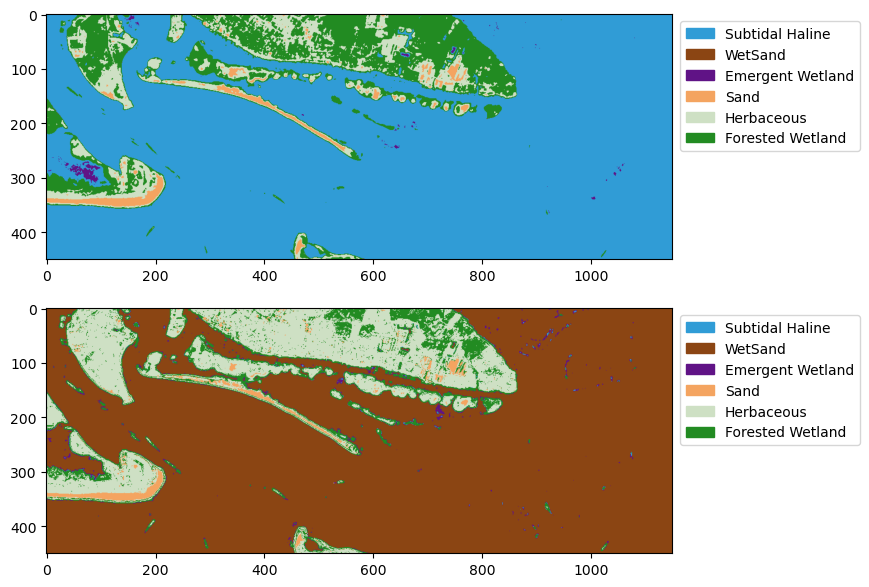

In [37]:
# predict all pixels in the study area using both models
all_pred_gnb = gnb_train.predict(reshaped_img.reshape(-1, 8))
all_pred_gnb = all_pred_gnb.reshape(reshaped_img[:, :, 0].shape)

all_pred_rf = rf_train.predict(reshaped_img.reshape(-1, 8))
all_pred_rf = all_pred_rf.reshape(reshaped_img[:, :, 0].shape)

all_pred_gnb_colors = np.vectorize(colors.get)(all_pred_gnb)
all_pred_gnb_colors = np.array(all_pred_gnb_colors)

all_pred_rf_colors = np.vectorize(colors.get)(all_pred_rf)
all_pred_rf_colors = np.array(all_pred_rf_colors)

# plot maps
fig, axs = plt.subplots(2,1,figsize=(10,7))
show(all_pred_gnb_colors[[0,1,2], :, :], ax=axs[0])
show(all_pred_rf_colors[[0,1,2], :, :], ax=axs[1])
axs[0].legend(handles=legend_patches, bbox_to_anchor=(1.31, 1))
axs[1].legend(handles=legend_patches, bbox_to_anchor=(1.31, 1));

12. The following three cells analyze NDVI and NDWI values for the study area.
    - The first cell reads in the data (again).
    - The second cell computes NDVI and NDWI and clips the results to the study area.
    - The third cell plots some maps.
    
    <br>
    
    - Read this [short article discussing NDVI and NDWI](https://www.auravant.com/en/articles/precision-agriculture/vegetation-indices-and-their-interpretation-ndvi-gndvi-msavi2-ndre-and-ndwi/) (it also discusses some other indexes).
    - Run the cells.
    - What is the possible range of values for NDVI and NDWI?
    - What is the minimum and maximum values for NDVI and NDWI for the study area?
    - Briefly interpret the the NDVI and NDWI maps.

In [38]:
with rasterio.open(img_fp) as src:
    green_band = src.read(3)
    red_band = src.read(4)
    nir_band = src.read(8)

In [39]:
ndwi = (green_band.astype(float) - nir_band.astype(float)) / (green_band.astype(float) + nir_band.astype(float))
ndvi = (nir_band.astype(float) - red_band.astype(float)) / (red_band.astype(float) + nir_band.astype(float))

ndwi = ndwi[150:600, 250:1400]
ndvi = ndvi[150:600, 250:1400]

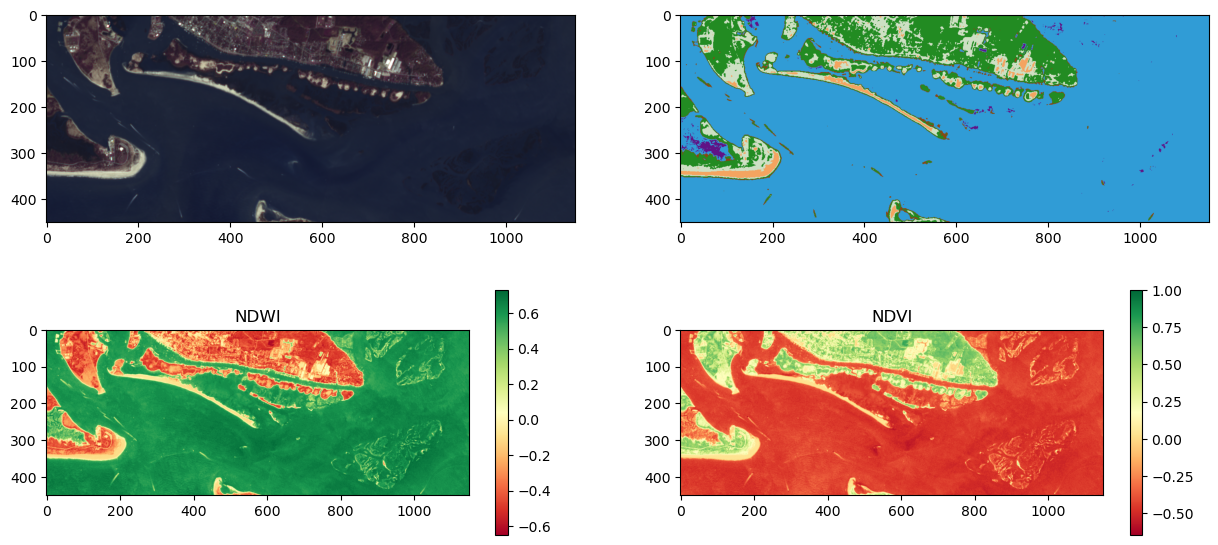

In [40]:
fig, axs = plt.subplots(2,2,figsize=(15,7))

show(img[[4,3,2], :, :], ax=axs[0,0])

show(class_pred_gnb_colors[[0,1,2], :, :], ax=axs[0,1])

nwdi_plot = axs[1,0].imshow(ndwi, cmap="RdYlGn")
axs[1,0].set_title("NDWI")
fig.colorbar(nwdi_plot, ax=axs[1,0])

ndvi_plot = axs[1,1].imshow(ndvi, cmap="RdYlGn")
axs[1,1].set_title("NDVI")
fig.colorbar(ndvi_plot, ax=axs[1,1])

plt.show()

13. The following cells run k-means clustering on the data. 
    - The first cell runs k-means for k=6 and k=10.
    - The second cell plots these results along with some of the earlier results.
    
    <br>
    
    - Naive Bayes and Random Forest are "supervised" machine learning models, while k-means is an "unsupervised" model. Read this [brief article on the difference between the two modeling types](https://cloud.google.com/discover/supervised-vs-unsupervised-learning). Feel free to read more on the differences.
    - Run the cells below.
    - Why can we only get 6 class types out of the supervised models, but we can get any number of classes from the unsupervised model?
    - Discuss some differences and similarities between the two k-means results. (Note: Consider the photo image also when answering. Remember that the colors will not necessarily match between the k=6 and k=10 maps.)
    - Discuss some differences and similarities between the k-means results and the supervised model results. 

In [43]:
from sklearn.cluster import KMeans

bands, rows, cols = img.shape

# k-means with k=6 to match the six classes from the other analyses
np.random.seed(1234)
kmeans6 = KMeans(n_clusters=6)
kmeans6_predictions = kmeans6.fit(reshaped_img.reshape(-1, 8))
kmeans6_predictions_2d = kmeans6_predictions.labels_.reshape(rows, cols)

# k-means with k=10 to see what happens
np.random.seed(5678)
kmeans10 = KMeans(n_clusters=10)
kmeans10_predictions = kmeans10.fit(reshaped_img.reshape(-1, 8))
kmeans10_predictions_2d = kmeans10_predictions.labels_.reshape(rows, cols)

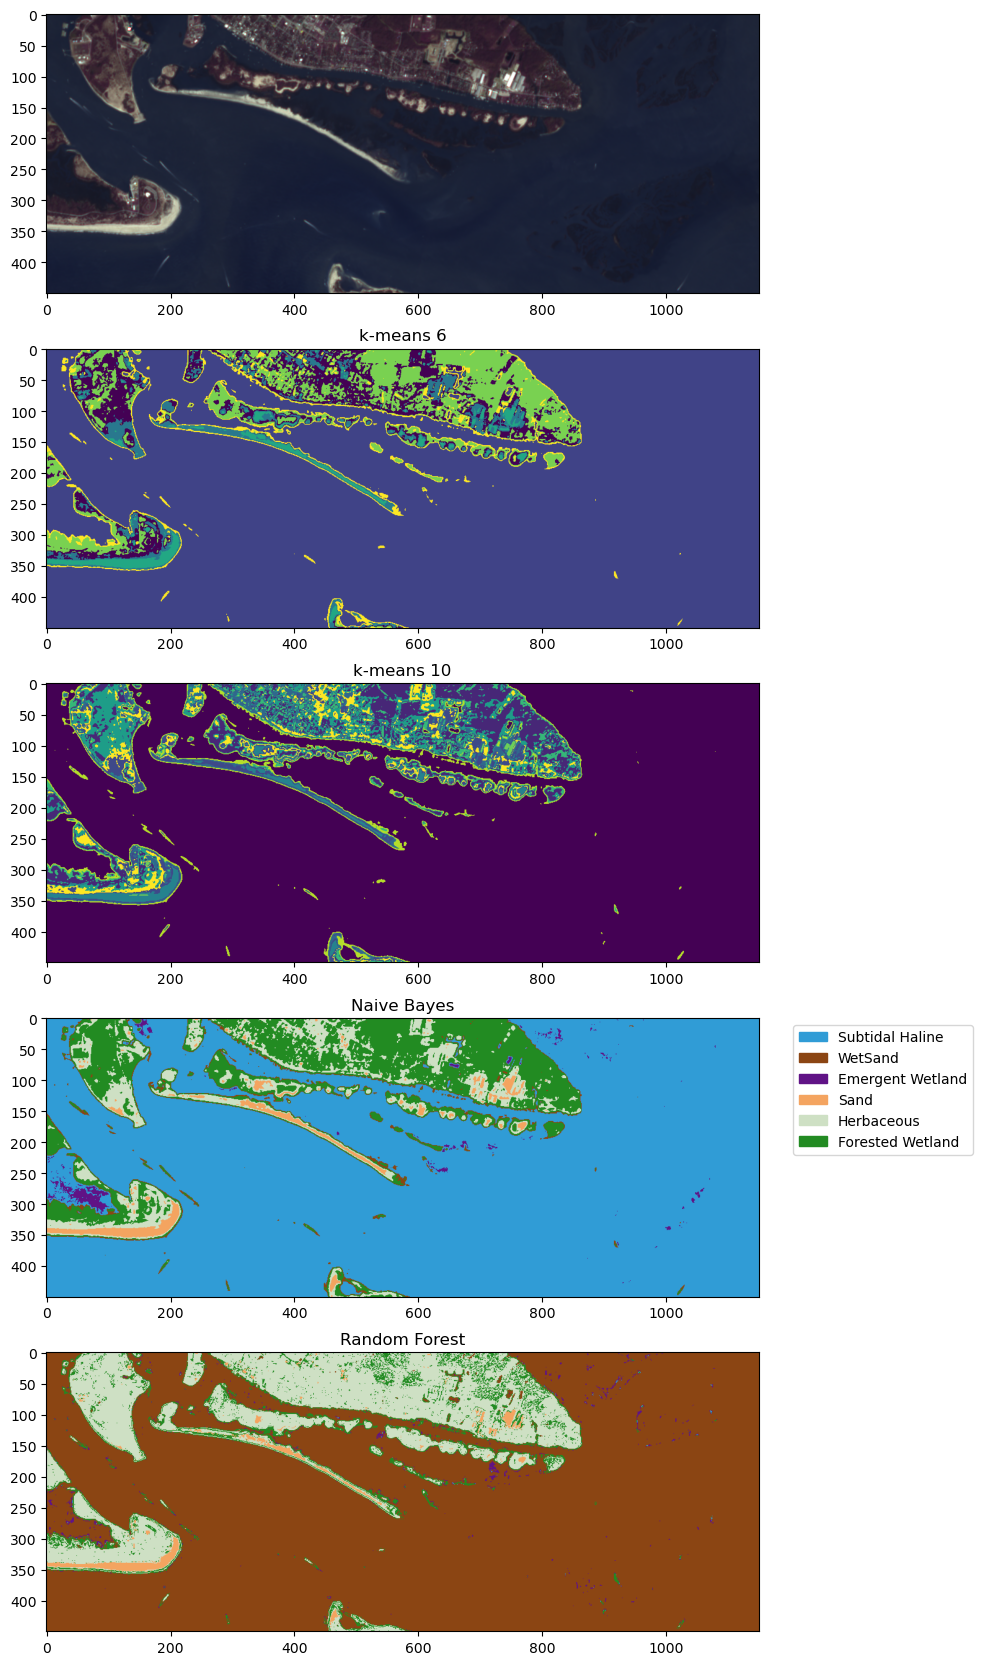

In [44]:
# plot some maps
fig, axs = plt.subplots(5,1,figsize=(10,21))

show(img[[4,3,2], :, :], ax=axs[0])
axs[1].imshow(kmeans6_predictions_2d)
axs[2].imshow(kmeans10_predictions_2d)
show(class_pred_gnb_colors[[0,1,2], :, :], ax=axs[3])
show(class_pred_rf_colors[[0,1,2], :, :], ax=axs[4])

axs[1].set_title('k-means 6')
axs[2].set_title('k-means 10')
axs[3].set_title('Naive Bayes')
axs[4].set_title('Random Forest')
axs[3].legend(handles=legend_patches, bbox_to_anchor=(1.31, 1));